<a href="https://colab.research.google.com/github/droyktton/ActiveInterface/blob/main/BenchmarkActiveInterface.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [54]:
!rm -rf ActiveInterface; git clone https://github.com/droyktton/ActiveInterface.git

Cloning into 'ActiveInterface'...
remote: Enumerating objects: 392, done.
remote: Counting objects: 100% (72/72), done.
remote: Compressing objects: 100% (54/54), done.
remote: Total 392 (delta 39), reused 33 (delta 17), pack-reused 320 (from 2)
Receiving objects: 100% (392/392), 2.08 MiB | 6.53 MiB/s, done.
Resolving deltas: 100% (239/239), done.


In [55]:
%%bash
git clone https://github.com/DEShawResearch/random123.git


fatal: destination path 'random123' already exists and is not an empty directory.


CalledProcessError: Command 'b'git clone https://github.com/DEShawResearch/random123.git\n'' returned non-zero exit status 128.

In [56]:
%%bash
cd ActiveInterface;
make clean;
make ANH C2=0.5 C4=0.0 C6=1.0 Dt=0.1 TAU=100 MONITOR=1000000000 MONITORCONF=1000000000 TEMP=1.0

rm -f activeinterface
nvcc --expt-extended-lambda -lcufft -std=c++17 -arch=sm_75 -gencode arch=compute_61,code=sm_61 -gencode arch=compute_80,code=sm_80 -gencode arch=compute_75,code=sm_75 -DNOMONITOR -DRANDOM123  -DC2=0.5 -DC4=0.0 -DC6=1.0 -DTAU=100 -DMONITOR=1000000000 -DDt=0.1 -DMONITORCONF=1000000000 -DTEMP=1.0  ew.cu -o activeinterface -L/opt/nvidia/hpc_sdk/Linux_x86_64/23.7/math_libs/12.2/lib64  -I/opt/nvidia/hpc_sdk/Linux_x86_64/23.7/math_libs/12.2/include -I/content/random123/include 


In [31]:
%%bash
#!/bin/bash

for i in {1..2}
do
  dir=run_$i
  echo "Running with seed $i in $dir"
  mkdir $dir
  cd $dir
  /content/ActiveInterface/activeinterface 32768 16385 $i
  cd ../
done

Running with seed 1 in run_1
Running with seed 2 in run_2


mkdir: cannot create directory ‘run_1’: File exists
bash: line 9: /content/ActiveInterface/activeinterface: No such file or directory
mkdir: cannot create directory ‘run_2’: File exists
bash: line 9: /content/ActiveInterface/activeinterface: No such file or directory


In [132]:
%%bash
#!/bin/bash

rm -f zzz.dat

i=1234
for L in 1024 4096 16384 32768 65536 131072
do
  echo $L $(/content/ActiveInterface/activeinterface $L 16385 $i | grep "Time taken:" | awk '{print $3}') >> zzz.dat
done



In [133]:

%%bash
cat zzz.dat


1024 0.650063
4096 0.789659
16384 1.94803
32768 4.11813
65536 7.13818
131072 14.5291


In [138]:
%%bash

#ncu --set full ./a.out


ncu --set launch /content/ActiveInterface/activeinterface 8192 16385 1234

Process is terminated.


In [53]:
%%bash

cat /content/logfile.dat


simple precision
TEMP= 1
MONITOR= 1000000000
MONITORCONF= 1000000000
C2= 0.5
C4= 0
TAU= 100
USING RANDOM123
dt= 0.1
L= 131072
Time taken: 14.4838 seconds
 L=131072 Nrun=16385
device= Tesla T4
Performance[s,L,Nrun]: 14.4838 131072 16385


# Task
Load the data from the `zzz.dat` file, which contains 'Size' and 'Time Taken' columns, into a Pandas DataFrame. Then, create a log-log scatter plot of 'Time Taken' versus 'Size' using Matplotlib, including labels, a title, and a grid. Finally, analyze the plot to understand the relationship between 'Size' and 'Time Taken'.

## Load Data

### Subtask:
Load the data from the `zzz.dat` file into a Pandas DataFrame. The file contains two columns: 'Size' and 'Time Taken'.


**Reasoning**:
To load the data from 'zzz.dat' into a DataFrame, I need to import the pandas library first. Then, I will use `pd.read_csv` to read the file, specifying that there is no header and providing the column names as 'Size' and 'Time Taken'. Finally, I will display the first few rows to verify the data.



In [15]:
import pandas as pd

df = pd.read_csv('zzz.dat', header=None, names=['Size', 'Time Taken'], sep=' ')
print("Data loaded successfully. Here are the first 5 rows:")
df.head()

Data loaded successfully. Here are the first 5 rows:


,Size,Time Taken
0,1024,0.653868
1,4096,0.825191
2,16384,2.010140
3,32768,3.890510
4,65536,7.317600


Slope (exponent of power law) for Size >= 16384: 0.9465
Intercept (log of coefficient) for Size >= 16384: -8.4887
R-squared for Size >= 16384: 0.9998


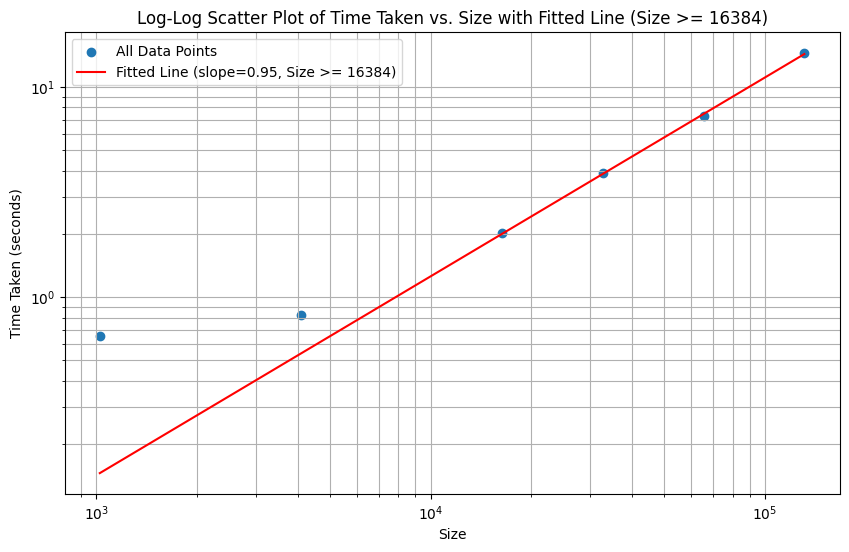

In [20]:
import numpy as np
from scipy.stats import linregress
import matplotlib.pyplot as plt

# Filter data for 'Size' >= 16384
filtered_df = df[df['Size'] >= 16384]

# Take the logarithm of 'Size' and 'Time Taken' from the filtered data
log_size = np.log(filtered_df['Size'])
log_time_taken = np.log(filtered_df['Time Taken'])

# Perform linear regression on the log-transformed filtered data
slope, intercept, r_value, p_value, std_err = linregress(log_size, log_time_taken)

print(f"Slope (exponent of power law) for Size >= 16384: {slope:.4f}")
print(f"Intercept (log of coefficient) for Size >= 16384: {intercept:.4f}")
print(f"R-squared for Size >= 16384: {r_value**2:.4f}")

# Create a new scatter plot with the fitted line
plt.figure(figsize=(10, 6))
plt.scatter(df['Size'], df['Time Taken'], label='All Data Points')

# Calculate the fitted line values (in original scale) for the full range for visualization
# Note: The regression was done on filtered_df, but we plot the fit over the range of the original data to see how it extrapolates/interpolates.
predicted_time_taken = np.exp(intercept + slope * np.log(df['Size']))
plt.plot(df['Size'], predicted_time_taken, color='red', label=f'Fitted Line (slope={slope:.2f}, Size >= 16384)')

# Set logarithmic scales for both axes
plt.xscale('log')
plt.yscale('log')

# Add labels and title
plt.xlabel('Size')
plt.ylabel('Time Taken (seconds)')
plt.title('Log-Log Scatter Plot of Time Taken vs. Size with Fitted Line (Size >= 16384)')

# Add a grid and legend
plt.grid(True, which="both", ls="-")
plt.legend()

# Display the plot
plt.show()


In [52]:
%%bash

cat /content/ActiveInterface/ew.cu
cat /content/ActiveInterface/Makefile


#ifdef RANDOM123
  #define R123_USE_CUDA
  #define R123_NO_SSE
  #include <Random123/philox.h>
#else
  #include <curand_kernel.h>
#endif

#include <thrust/device_vector.h>
#include <thrust/host_vector.h>
#include <thrust/for_each.h>
#include <thrust/iterator/zip_iterator.h>
#include <thrust/iterator/counting_iterator.h>
#include <thrust/tuple.h>
#include <thrust/reduce.h>
#include <thrust/copy.h>
#include <fstream>
#include <cstdlib>
#include <thrust/transform_reduce.h>
#include <thrust/transform.h>
#include <cufft.h>
#include "cutil.h"
#include <chrono>
#include <iomanip>
#include <thrust/complex.h>


#ifdef RANDOM123
using philox_t = r123::Philox4x32;
__device__ inline float rng_normal(uint32_t i, uint32_t n, uint32_t seed)
{
    philox_t::key_type key = {{seed, 0}};
    philox_t::ctr_type ctr = {{i, n, 0, 0}};
    philox_t::ctr_type out = philox_t()(ctr, key);

    // Box–Muller using two 32-bit outputs
    float u1 = (out[0] + 1.0f) * 2.3283064e-10f;
    float u2 = (out[1] + 1.0f) 

# CURAND vs RANDOM123 philox

In [91]:
%%writefile rng_bench.cu
// rng_bench.cu
// Compile with either:
//   nvcc -O3 rng_bench.cu -DUSE_CURAND
// or
//   nvcc -O3 rng_bench.cu -I/path/to/random123/include
//
// (never both at once)

#include <cstdio>
#include <cuda.h>

constexpr int THREADS = 256;
constexpr int BLOCKS  = 65536;
constexpr int ITERS   = 2048;

#ifdef USE_CURAND
  #include <curand_kernel.h>
#else
  #define R123_USE_CUDA
  #define R123_NO_SSE
  #include <Random123/philox.h>
  using philox_t = r123::Philox4x32;
#endif

// ------------------------------------------------------------
// Kernel
// ------------------------------------------------------------
#ifdef USE_CURAND

__global__ void rng_kernel(float* out, unsigned long long seed)
{
    int tid = blockIdx.x * blockDim.x + threadIdx.x;

    curandStatePhilox4_32_10_t state;
    curand_init(seed, tid, 0, &state);

    float acc = 0.f;
    #pragma unroll
    for (int i = 0; i < ITERS; ++i) {
        float4 r = curand_uniform4(&state);
        acc += r.x + r.y + r.z + r.w;
    }
    out[tid] = acc;
}

#else

__global__ void rng_kernel(float* out, unsigned long long seed)
{
    int tid = blockIdx.x * blockDim.x + threadIdx.x;

    philox_t::key_type key = {{
        (uint32_t)seed, (uint32_t)(seed >> 32)
    }};
    philox_t::ctr_type ctr = {{ (uint32_t)tid, 0, 0, 0 }};

    float acc = 0.f;
    constexpr float norm = 2.3283064365386963e-10f; // 1/2^32

    #pragma unroll
    for (int i = 0; i < ITERS; ++i) {
        ctr.v[1] = i;
        auto r = philox_t()(ctr, key);
        acc += r.v[0] * norm;
        acc += r.v[1] * norm;
        acc += r.v[2] * norm;
        acc += r.v[3] * norm;
    }
    out[tid] = acc;
}

#endif

// ------------------------------------------------------------
// Timing helper
// ------------------------------------------------------------
float run(float* d_out)
{
    cudaEvent_t start, stop;
    cudaEventCreate(&start);
    cudaEventCreate(&stop);

    cudaEventRecord(start);
    rng_kernel<<<BLOCKS, THREADS>>>(d_out, 1234ULL);
    cudaEventRecord(stop);

    cudaEventSynchronize(stop);

    float ms = 0.f;
    cudaEventElapsedTime(&ms, start, stop);

    cudaEventDestroy(start);
    cudaEventDestroy(stop);
    return ms;
}

// ------------------------------------------------------------
// Main
// ------------------------------------------------------------
int main()
{
    float* d_out;
    cudaMalloc(&d_out, BLOCKS * THREADS * sizeof(float));

    // warmup
    rng_kernel<<<BLOCKS, THREADS>>>(d_out, 1234ULL);
    cudaDeviceSynchronize();

    float t = run(d_out);

#ifdef USE_CURAND
    printf("curand Philox:    %.3f ms\n", t);
#else
    printf("Random123 Philox: %.3f ms\n", t);
#endif

    cudaFree(d_out);
    return 0;
}


Overwriting rng_bench.cu


In [92]:
%%bash

nvcc rng_bench.cu -DUSE_CURAND -O3 -o bench_curand
nvcc rng_bench.cu -I/content/random123/include -O3 -o bench_random123


In [94]:
%%bash

./bench_curand
./bench_random123

curand Philox:    0.004 ms
Random123 Philox: 0.003 ms


# powf for integer exponents ?

In [105]:
%%writefile pow_bench.cu
// pow_bench.cu
// nvcc -O3 pow_bench.cu -o pow_bench

#include <cstdio>
#include <cuda.h>

constexpr int N       = 1 << 28;   // millions of elements
constexpr int ITERS   = 32;

// ------------------------------------------------------------
// powf version
// ------------------------------------------------------------
__global__ void powf_kernel(const float* x, float* out)
{
    int i = blockIdx.x * blockDim.x + threadIdx.x;
    if (i >= N) return;

    float v = x[i];
    float acc = 0.f;

    #pragma unroll
    for (int k = 0; k < ITERS; ++k) {
        acc += powf(v, 5.0f);
    }

    out[i] = acc;
}

// ------------------------------------------------------------
// manual multiplication version
// ------------------------------------------------------------
__global__ void mul_kernel(const float* x, float* out)
{
    int i = blockIdx.x * blockDim.x + threadIdx.x;
    if (i >= N) return;

    float v = x[i];
    float v2 = v * v;
    float v4 = v2 * v2;
    float v5 = v4 * v;

    float acc = 0.f;

    #pragma unroll
    for (int k = 0; k < ITERS; ++k) {
        acc += v5;
    }

    out[i] = acc;
}

// ------------------------------------------------------------
// timing helper
// ------------------------------------------------------------
float time_kernel(void (*kernel)(const float*, float*),
                  const float* x, float* out)
{
    cudaEvent_t start, stop;
    cudaEventCreate(&start);
    cudaEventCreate(&stop);

    dim3 block(256);
    dim3 grid((N + block.x - 1) / block.x);

    cudaEventRecord(start);
    kernel<<<grid, block>>>(x, out);
    cudaEventRecord(stop);

    cudaEventSynchronize(stop);

    float ms = 0.f;
    cudaEventElapsedTime(&ms, start, stop);

    cudaEventDestroy(start);
    cudaEventDestroy(stop);
    return ms;
}

// ------------------------------------------------------------
// main
// ------------------------------------------------------------
int main()
{
    float *x, *out;
    cudaMalloc(&x,   N * sizeof(float));
    cudaMalloc(&out, N * sizeof(float));

    // initialize x
    cudaMemset(x, 0, N * sizeof(float));

    // warmup
    powf_kernel<<<(N+255)/256,256>>>(x, out);
    mul_kernel <<< (N+255)/256,256>>>(x, out);
    cudaDeviceSynchronize();

    float t_pow = time_kernel(powf_kernel, x, out);
    float t_mul = time_kernel(mul_kernel,  x, out);

    printf("powf(x,5):     %.3f ms\n", t_pow);
    printf("manual x^5:    %.3f ms\n", t_mul);
    printf("speedup:       %.2fx\n", t_pow / t_mul);

    cudaFree(x);
    cudaFree(out);
    return 0;
}


Overwriting pow_bench.cu


In [120]:
%%bash

nvcc pow_bench.cu -o pow_bench

In [122]:
%%bash

./pow_bench > zzz

for((i=0;i<10;i++))
do
  ./pow_bench
  echo
done

powf(x,5):     0.003 ms
manual x^5:    0.002 ms
speedup:       1.04x

powf(x,5):     0.004 ms
manual x^5:    0.002 ms
speedup:       1.75x

powf(x,5):     0.002 ms
manual x^5:    0.002 ms
speedup:       1.20x

powf(x,5):     0.004 ms
manual x^5:    0.002 ms
speedup:       1.58x

powf(x,5):     0.004 ms
manual x^5:    0.002 ms
speedup:       1.59x

powf(x,5):     0.003 ms
manual x^5:    0.002 ms
speedup:       1.26x

powf(x,5):     0.003 ms
manual x^5:    0.002 ms
speedup:       1.26x

powf(x,5):     0.003 ms
manual x^5:    0.002 ms
speedup:       1.53x

powf(x,5):     0.003 ms
manual x^5:    0.002 ms
speedup:       1.65x

powf(x,5):     0.002 ms
manual x^5:    0.002 ms
speedup:       1.00x



# raw kernel vs thrust::for_each ?

In [123]:
%%writefile raw_vs_thrust.cu
#include <cstdio>
#include <thrust/device_vector.h>
#include <thrust/for_each.h>
#include <thrust/execution_policy.h>

#define N (1<<24)
#define BLOCK 256

// ---------------- RAW CUDA KERNEL ----------------
__global__ void raw_kernel(const float* x, float* y, int n)
{
    int i = blockIdx.x * blockDim.x + threadIdx.x;
    if (i < n) {
        float v = x[i];
        float v2 = v * v;
        y[i] = v2 * v2 * v;  // x^5
    }
}

// ---------------- THRUST FUNCTOR ----------------
struct pow5_functor {
    const float* x;
    float* y;

    __host__ __device__
    void operator()(int i) const {
        float v = x[i];
        float v2 = v * v;
        y[i] = v2 * v2 * v;
    }
};

float time_raw(const float* x, float* y)
{
    cudaEvent_t start, stop;
    cudaEventCreate(&start);
    cudaEventCreate(&stop);

    int grid = (N + BLOCK - 1) / BLOCK;

    cudaEventRecord(start);
    raw_kernel<<<grid, BLOCK>>>(x, y, N);
    cudaEventRecord(stop);
    cudaEventSynchronize(stop);

    float ms;
    cudaEventElapsedTime(&ms, start, stop);
    return ms;
}

float time_thrust(const float* x, float* y)
{
    cudaEvent_t start, stop;
    cudaEventCreate(&start);
    cudaEventCreate(&stop);

    cudaEventRecord(start);
    thrust::for_each(
        thrust::device,
        thrust::counting_iterator<int>(0),
        thrust::counting_iterator<int>(N),
        pow5_functor{x, y}
    );
    cudaEventRecord(stop);
    cudaEventSynchronize(stop);

    float ms;
    cudaEventElapsedTime(&ms, start, stop);
    return ms;
}

int main()
{
    thrust::device_vector<float> x(N, 1.001f);
    thrust::device_vector<float> y(N);

    const float* xptr = thrust::raw_pointer_cast(x.data());
    float* yptr = thrust::raw_pointer_cast(y.data());

    // Warmup
    time_raw(xptr, yptr);
    time_thrust(xptr, yptr);

    float t_raw = time_raw(xptr, yptr);
    float t_thr = time_thrust(xptr, yptr);

    printf("raw kernel:      %.3f ms\n", t_raw);
    printf("thrust::for_each %.3f ms\n", t_thr);
    printf("speedup:         %.2fx\n", t_thr / t_raw);
}


Writing raw_vs_thrust.cu


In [128]:
%%bash

nvcc -arch=sm_75 raw_vs_thrust.cu -o raw_vs_thrust

In [131]:
%%bash

for((i=0;i<10;i++))
do
  ./raw_vs_thrust | grep "speedup"
done

speedup:         0.96x
speedup:         0.96x
speedup:         0.97x
speedup:         0.96x
speedup:         0.96x
speedup:         0.96x
speedup:         0.96x
speedup:         0.96x
speedup:         0.95x
speedup:         0.96x
